In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from gensim.models import Word2Vec
from gensim.models import KeyedVectors

# Download required NLTK data
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df_train_main = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/train.csv', encoding='ISO-8859-1')
df_test_main = pd.read_csv('/kaggle/input/sentiment-analysis-dataset/test.csv', encoding='ISO-8859-1')

In [3]:
df_train  = df_train_main[['text','sentiment']]
df_train.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [4]:
df_test  = df_test_main[['text','sentiment']]
df_test.head()

,text,sentiment
0,Last session of the day http://twitpic.com/67ezh,neutral
1,Shanghai is also really exciting (precisely -...,positive
2,"Recession hit Veronique Branquinho, she has to...",negative
3,happy bday!,positive
4,http://twitpic.com/4w75p - I like it!!,positive


In [5]:
df_train.shape, df_test.shape

((27481, 2), (4815, 2))

### Text preprocessing

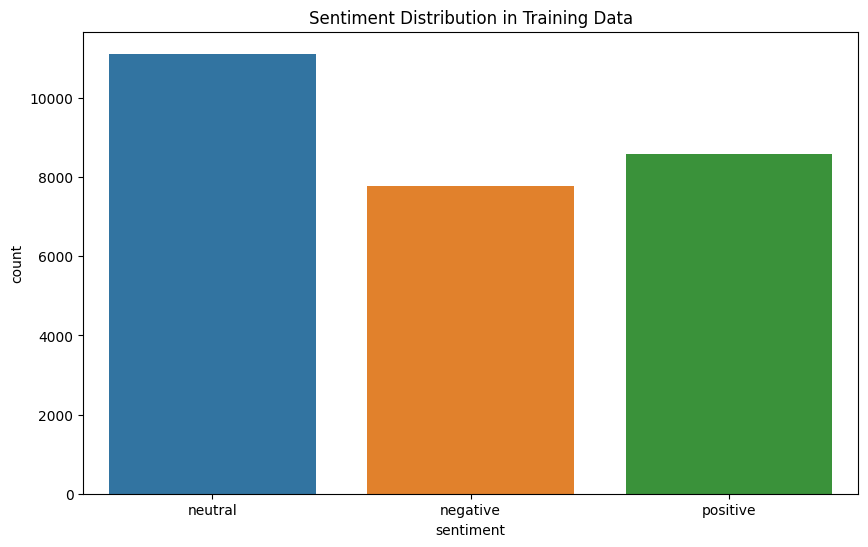

In [6]:
# Visualize sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='sentiment', data=df_train)
plt.title('Sentiment Distribution in Training Data')
plt.show()

In [7]:
# Map text sentiments to numeric values
sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_train['sentiment'] = df_train['sentiment'].str.lower().map(sentiment_map)
df_test['sentiment'] = df_test['sentiment'].str.lower().map(sentiment_map)

/tmp/ipykernel_35/707221107.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['sentiment'] = df_train['sentiment'].str.lower().map(sentiment_map)
/tmp/ipykernel_35/707221107.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['sentiment'] = df_test['sentiment'].str.lower().map(sentiment_map)


In [8]:
# Remove any rows with NaN values
df_train = df_train.dropna()
df_test = df_test.dropna()

In [9]:
df_train.head()

,text,sentiment
0,"I`d have responded, if I were going",1
1,Sooo SAD I will miss you here in San Diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"Sons of ****, why couldn`t they put them on t...",0


In [ ]:
import re

def preprocess_text(text):
    if not isinstance(text, str):
        text = str(text)
    
    # Replace backtick with apostrophe
    text = text.replace('`', "'")
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs and emails
    text = re.sub(r'https?://\S+|www\.\S+|\S+@\S+', '', text)
    
    # Alphanumeric, asterisks, apostrophes, and basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s\*\'!?,.]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [11]:
# Apply preprocessing to both train and test sets
df_train['text'] = df_train['text'].apply(preprocess_text)
df_test['text'] = df_test['text'].apply(preprocess_text)

In [12]:
df_train.head()

,text,sentiment
0,"i'd have responded, if i were going",1
1,sooo sad i will miss you here in san diego!!!,0
2,my boss is bullying me...,0
3,what interview! leave me alone,0
4,"sons of ****, why couldn't they put them on th...",0


### Stop Word Removal
Stop word removal is not performed in sentiment analysis.

Reason: Stop words like "not" or "very" can carry significant meaning in sentiment analysis (e.g., "not happy" or "very good"). Removing them might alter the sentiment of the text.

### Tokenzation and Lemmatization

Stemming is not used as lemmatization takes pos into consideration

In [13]:
# Lemmatization

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
import pandas as pd

# initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def lemmatize_text(text):
    # Ensure text is string
    if not isinstance(text, str):
        text = str(text)
    # Tokenize
    tokens = word_tokenize(text)
    # Lemmatize and join back into text
    return ' '.join([lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens])

In [14]:
# Apply lemmatization and keep as text
df_train['processed_text'] = df_train['text'].apply(lemmatize_text)
df_test['processed_text'] = df_test['text'].apply(lemmatize_text)

In [15]:
df_train[['text','processed_text']].head()

,text,processed_text
0,"i'd have responded, if i were going","i 'd have respond , if i be go"
1,sooo sad i will miss you here in san diego!!!,sooo sad i will miss you here in san diego ! ! !
2,my boss is bullying me...,my bos be bullying me ...
3,what interview! leave me alone,what interview ! leave me alone
4,"sons of ****, why couldn't they put them on th...","son of * * * * , why could n't they put them o..."


#### Representation, train and evaluate
- Text Representations
- Train a logistic regression
- Evaluate the model


In [16]:
# Prepare features and labels
X_train = df_train['processed_text']
X_test = df_test['processed_text']

y_train = df_train['sentiment']
y_test = df_test['sentiment']

In [17]:
def train_and_evaluate(X_train_vec, X_test_vec, y_train, y_test, model_name="Model"):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    print(f"\n{model_name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

In [18]:
# 1. Bag of Words (BoW)
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
train_and_evaluate(X_train_bow, X_test_bow, y_train, y_test, "Bag of Words")


Bag of Words Accuracy: 0.7074
              precision    recall  f1-score   support

         0.0       0.71      0.66      0.69      1001
         1.0       0.65      0.73      0.69      1430
         2.0       0.79      0.73      0.75      1103

    accuracy                           0.71      3534
   macro avg       0.72      0.70      0.71      3534
weighted avg       0.71      0.71      0.71      3534



In [19]:
# 2. TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
train_and_evaluate(X_train_tfidf, X_test_tfidf, y_train, y_test, "TF-IDF (All Data)")


TF-IDF (All Data) Accuracy: 0.7153
              precision    recall  f1-score   support

         0.0       0.73      0.65      0.69      1001
         1.0       0.65      0.75      0.70      1430
         2.0       0.81      0.72      0.76      1103

    accuracy                           0.72      3534
   macro avg       0.73      0.71      0.72      3534
weighted avg       0.72      0.72      0.72      3534



In [ ]:
# 3. Word2Vec

# Prepare sentences for Word2Vec
train_sentences = [text.split() for text in X_train]
test_sentences = [text.split() for text in X_test]

# Initialize and train Word2Vec model
w2v_model = Word2Vec(sentences=train_sentences,
                    vector_size=100,
                    window=5,
                    min_count=2,
                    workers=4)

# Training
w2v_model.train(train_sentences,
                total_examples=len(train_sentences),
                epochs=10)

# Function to create document vectors
def get_document_vector(text, model, vector_size=100):
    words = text.split()
    word_vecs = [model.wv[word] for word in words if word in model.wv]
    if len(word_vecs) > 0:
        return np.mean(word_vecs, axis=0)
    return np.zeros(vector_size)

# Create document vectors
X_train_w2v = np.array([get_document_vector(text, w2v_model) for text in X_train])
X_test_w2v = np.array([get_document_vector(text, w2v_model) for text in X_test])

# Train and evaluate Word2Vec
train_and_evaluate(X_train_w2v, X_test_w2v, y_train, y_test, "Word2Vec")


Word2Vec Accuracy: 0.6293
              precision    recall  f1-score   support

         0.0       0.65      0.51      0.57      1001
         1.0       0.57      0.71      0.63      1430
         2.0       0.73      0.64      0.68      1103

    accuracy                           0.63      3534
   macro avg       0.65      0.62      0.63      3534
weighted avg       0.64      0.63      0.63      3534



In [21]:
import gensim.downloader as api

# 4. Pre-trained GloVe
# Download pre-trained GloVe vectors
print("Downloading GloVe vectors...")
glove_vectors = api.load("glove-wiki-gigaword-100")

# Function to create document vectors using GloVe
def get_glove_vector(text, model, vector_size=100):
    words = text.split()
    word_vecs = [model[word] for word in words if word in model]
    if len(word_vecs) > 0:
        return np.mean(word_vecs, axis=0)
    return np.zeros(vector_size)

# Create document vectors using GloVe
X_train_glove = np.array([get_glove_vector(text, glove_vectors) for text in X_train])
X_test_glove = np.array([get_glove_vector(text, glove_vectors) for text in X_test])

# Train and evaluate GloVe
train_and_evaluate(X_train_glove, X_test_glove, y_train, y_test, "GloVe")

# GloVe analysis
print("\nGloVe - Similar words to negative sentiment words:")
negative_words = ['bad', 'horrible', 'terrible', 'awful']
for word in negative_words:
    try:
        similar_words = glove_vectors.most_similar(word, topn=5)
        print(f"\n{word} -> {similar_words}")
    except:
        continue

[==================================================] 100.0% 128.1/128.1MB downloaded

GloVe Accuracy: 0.6121
              precision    recall  f1-score   support

         0.0       0.63      0.53      0.58      1001
         1.0       0.56      0.68      0.61      1430
         2.0       0.69      0.60      0.64      1103

    accuracy                           0.61      3534
   macro avg       0.63      0.60      0.61      3534
weighted avg       0.62      0.61      0.61      3534


GloVe - Similar words to negative sentiment words:

bad -> [('worse', 0.7929712533950806), ('good', 0.7702797651290894), ('things', 0.7653602957725525), ('too', 0.7630148530006409), ('thing', 0.7609667778015137)]

horrible -> [('awful', 0.921971321105957), ('terrible', 0.919477105140686), ('horrendous', 0.8366580605506897), ('dreadful', 0.8184822797775269), ('horrific', 0.8176026344299316)]

terrible -> [('horrible', 0.9194772243499756), ('awful', 0.8742169737815857), ('dreadful', 0.7821513414382935), ('